# DATA SCIENTIST: BREEZY_360
### Guava (Psidium guajava) is a key crop in South Asia, especially in Bangladesh. Rich in vitamin C and fiber,it supports regional economies and nutrition. Unfortunately, guava production is threatened by diseases that reduce yields. The following are the deep learning model that used to for early disease detection in guava fruit, helping to protect harvests and reduce economic losses.

In [1]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns

import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, AveragePooling2D
from tensorflow.keras.utils import image_dataset_from_directory

import os
import random

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Create the train dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory=r"C:\\Users\\Admin\\OneDrive\\Desktop\\Guava\\Guava\\GuavaDiseaseDataset\\GuavaDiseaseDataset\\train",
    labels='inferred',
    label_mode='categorical',
    batch_size=64,
    image_size=(256, 256)
)

# Create the validation dataset
test_ds = keras.utils.image_dataset_from_directory(
    directory= r"C:\\Users\\Admin\\OneDrive\\Desktop\\Guava\\Guava\\GuavaDiseaseDataset\\GuavaDiseaseDataset\\val",
    labels='inferred',
    label_mode='categorical',
    batch_size=64,
    image_size=(256, 256)
)

Found 2647 files belonging to 3 classes.
Found 755 files belonging to 3 classes.


In [3]:
#This function randomly displays a few images from a given folder so you can quickly inspect 
#your dataset visually. It's commonly used in machine learning/deep learning projects to confirm
#if images are loaded correctly, check quality, or see class examples.
def visualize_images(path, num_images=5):

    # Get a list of image filenames
    image_filenames = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

    if not image_filenames:
        raise ValueError("No images found in the specified path")

    # Select random images
    selected_images = random.sample(image_filenames, min(num_images, len(image_filenames)))

    # Create a figure and axes
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3), facecolor='white')

    # Display each image
    for i, image_filename in enumerate(selected_images):
        # Load image
        image_path = os.path.join(path, image_filename)
        image = plt.imread(image_path)

        # Display image
        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(image_filename)  # Set image filename as title

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

In [4]:
# Extrating the class labels
classes = train_ds.class_names

ANTHRACNOSE


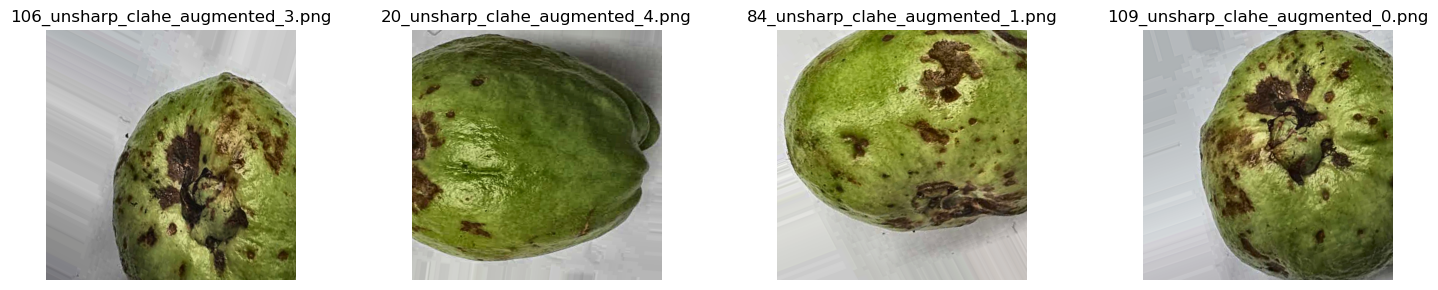

FRUIT_FLY


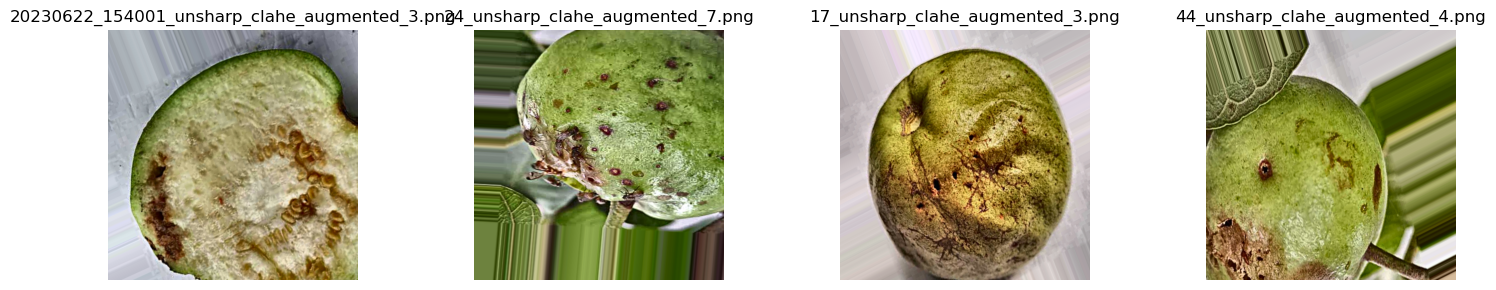

HEALTHY_GUAVA


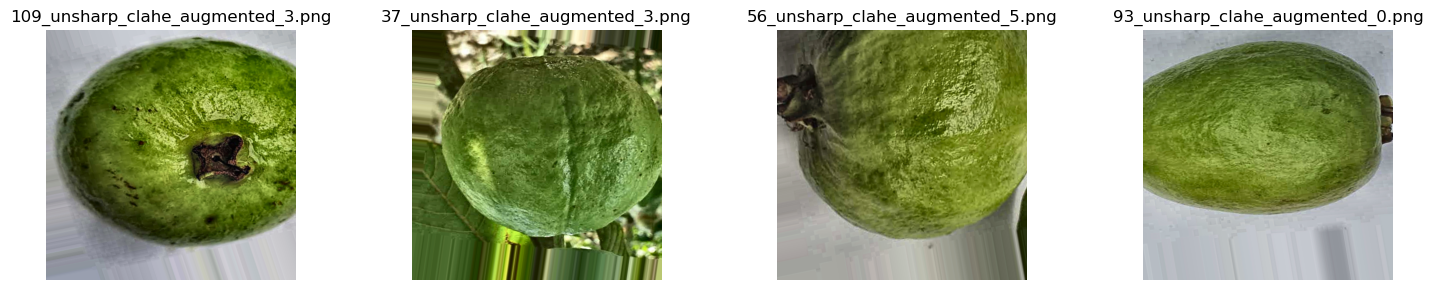

In [5]:
# Iterating through each class to plot its images
for label in classes:
    
    # Specify the path containing the images to visualize
    path_to_visualize = f"C:\\Users\\Admin\\OneDrive\\Desktop\\Guava\\Guava\\GuavaDiseaseDataset\\GuavaDiseaseDataset\\val\\{label}"

    # Visualize 3 random images
    print(label.upper())
    visualize_images(path_to_visualize, num_images=4)

In [25]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3, 3),activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(64,kernel_size=(3, 3),activation='relu'))
model.add(MaxPooling2D())


model.add(Conv2D(128,kernel_size=(3, 3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(3, activation='softmax'))

In [26]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 254, 254, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │      14,745,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,849,539 (56.65 MB)

 Trainable params: 14,849,475 (56.65 MB)

 Non-trainable params: 64 (256.00 B)

In [27]:
model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
history = model.fit(train_ds, epochs=10, batch_size = 128, validation_data=test_ds, verbose=1)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 989s 23s/step - accuracy: 0.4243 - loss: 2.1184 - val_accuracy: 0.3470 - val_loss: 2.2975
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 606s 14s/step - accuracy: 0.7563 - loss: 0.5558 - val_accuracy: 0.3523 - val_loss: 3.8078
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 368s 9s/step - accuracy: 0.9426 - loss: 0.1537 - val_accuracy: 0.5311 - val_loss: 1.5757
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 353s 8s/step - accuracy: 0.9758 - loss: 0.0792 - val_accuracy: 0.7907 - val_loss: 0.5164
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 344s 8s/step - accuracy: 0.9856 - loss: 0.0404 - val_accuracy: 0.9126 - val_loss: 0.2439
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 353s 8s/step - accuracy: 0.9788 - loss: 0.0551 - val_accuracy: 0.8887 - val_loss: 0.3088
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 352s 8s/step - accuracy: 0.9807 - loss: 0.0485 - val_accuracy: 0.8980 - val_loss: 0.3166
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 369s 9s/step - accuracy: 0.9970 - loss: 0.0102 - val_accuracy: 0.9219 -

In [29]:
history.history

{'accuracy': [0.4242538809776306,
  0.7563279271125793,
  0.94257652759552,
  0.9758216738700867,
  0.9856441020965576,
  0.9788439869880676,
  0.9807329177856445,
  0.996977686882019,
  0.9992444515228271,
  0.9996222257614136],
 'loss': [2.118389844894409,
  0.5557796955108643,
  0.15368977189064026,
  0.07916446775197983,
  0.040409404784440994,
  0.055140744894742966,
  0.04845951497554779,
  0.01022795494645834,
  0.00494270958006382,
  0.0015844686422497034],
 'val_accuracy': [0.34701988101005554,
  0.3523178696632385,
  0.5311258435249329,
  0.7907284498214722,
  0.9125827550888062,
  0.8887417316436768,
  0.8980132341384888,
  0.9218543171882629,
  0.940397322177887,
  0.9549669027328491],
 'val_loss': [2.297478437423706,
  3.807809352874756,
  1.5756500959396362,
  0.5163629055023193,
  0.24389046430587769,
  0.30879291892051697,
  0.31657496094703674,
  0.2841188311576843,
  0.20766910910606384,
  0.16231244802474976]}

In [1]:
# 📊 Plot training vs validation accuracy
plt.figure(figsize=(10, 4))
# ---- Accuracy ----
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# ---- Loss ----
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [33]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9550 - loss: 0.1623
Test Loss: 0.16231243312358856
Test Accuracy: 0.9549669027328491


In [42]:
from tensorflow.keras.preprocessing import image

# Load a new image
img_path1 = 'C:\\Users\\Admin\\OneDrive\\Desktop\\Guava\\Guava\\GuavaDiseaseDataset\\GuavaDiseaseDataset\\test\\healthy_guava\\12_unsharp_clahe_augmented_7.png'  
img = image.load_img(img_path1, target_size=(256, 256))

# Preprocess the image
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0  # Normalize the image (if you did this in training)

# Predict the class of the image
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions, axis=1)

# Print the predicted class
print(f"Predicted class: {classes[predicted_class[0]]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted class: Anthracnose


## PRE - TRAINED DATA

In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D

# Load pre-trained VGG16 model without the top layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Freeze the base model
base_model.trainable = False

# Create a new model with the pre-trained base model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
hist = model.fit(train_ds, epochs=10, batch_size=128, validation_data=test_ds, verbose=1)


Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1242s 29s/step - accuracy: 0.8043 - loss: 0.5643 - val_accuracy: 0.9272 - val_loss: 0.2042
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 953s 23s/step - accuracy: 0.9634 - loss: 0.1043 - val_accuracy: 0.9669 - val_loss: 0.0916
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 958s 23s/step - accuracy: 0.9796 - loss: 0.0619 - val_accuracy: 0.9616 - val_loss: 0.1117
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1017s 24s/step - accuracy: 0.9894 - loss: 0.0357 - val_accuracy: 0.9762 - val_loss: 0.0497
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1013s 24s/step - accuracy: 0.9940 - loss: 0.0216 - val_accuracy: 0.9762 - val_loss: 0.0754
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1039s 24s/step - accuracy: 0.9955 - loss: 0.0188 - val_accuracy: 0.9828 - val_loss: 0.0367
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1017s 24s/step - accuracy: 0.9981 - loss: 0.0104 - val_accuracy: 0.9828 - val_loss: 0.0439
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1018s 24s/step - accuracy: 0.9996 - loss: 0.0062 - val_accura

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 8, 8, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,942,987 (57.00 MB)

 Trainable params: 76,099 (297.26 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 152,200 (594.54 KB)

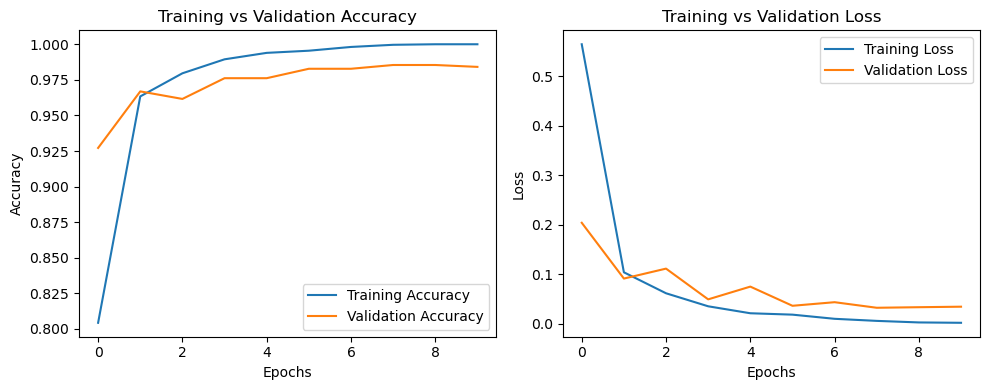

In [24]:
# 📊 Plot training vs validation accuracy
plt.figure(figsize=(10, 4))
# ---- Accuracy ----
plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='Training Accuracy')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# ---- Loss ----
plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='Training Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
test_dsT = keras.utils.image_dataset_from_directory(
    directory= r"C:\\Users\\Admin\\OneDrive\\Desktop\\Guava\\Guava\\GuavaDiseaseDataset\\GuavaDiseaseDataset\\test",
    labels='inferred',
    label_mode='categorical',
    batch_size=64,
    image_size=(256, 256)
)

Found 382 files belonging to 3 classes.


In [26]:
#test accuracy of the model
test_loss, test_acc = model.evaluate(test_dsT)
print('Test accuracy:', test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 119s 18s/step - accuracy: 0.9817 - loss: 0.0396
Test accuracy: 0.981675386428833


In [11]:
model.save(r"C:\\Users\\Admin\\OneDrive\\Desktop\\Guava\\Guava\\guava_ugonjwa\\Guava_diseases.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


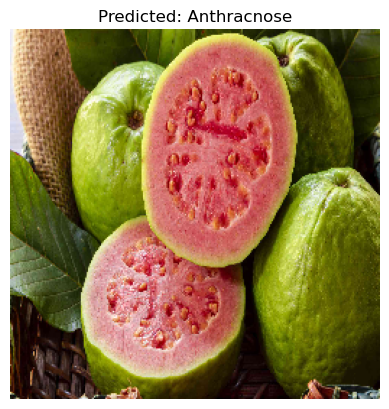

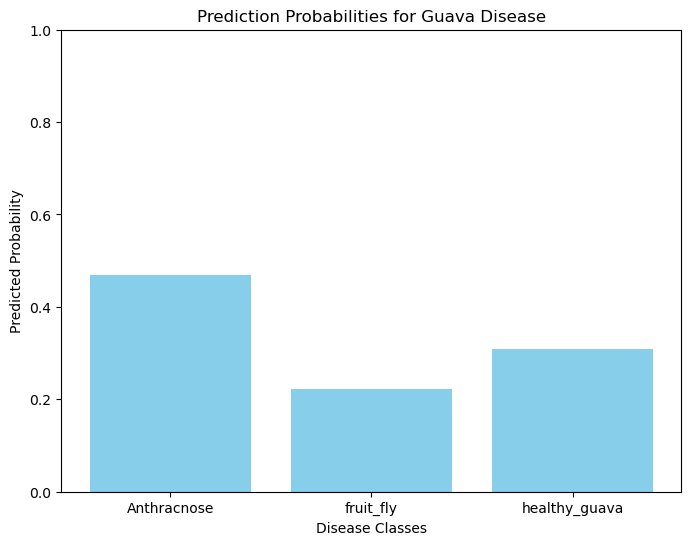

[0.4693379  0.22138289 0.30927923]
Predicted Disease: Anthracnose


In [51]:
# Define the class labels (replace this if you have a different list of class names)
classes = ['Anthracnose', 'fruit_fly', 'healthy_guava']  # Replace with your actual class names

# Function to upload, predict, and plot the result
def predict_disease_with_graph(image_path):
    # Load the image and resize it to the expected input size (256x256)
    img = image.load_img(image_path, target_size=(256, 256))
    
    # Convert the imae to an array
    img_array = image.img_to_array(img)
    
    # Expand dimensions to match the batch size (1 image in the batch)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Normalize the image (if you normalized during training)
    img_array = img_array / 255.0
    
    # Predict the class probabilities
    predictions = model.predict(img_array)
    
    # Get the predicted class (index of the highest probability)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    
    # Get the predicted class label
    predicted_class = classes[predicted_class_index]
    
    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class}")
    plt.show()

    # Plotting the prediction probabilities as a bar chart
    plt.figure(figsize=(8, 6))
    plt.bar(classes, predictions[0], color='skyblue')
    plt.xlabel('Disease Classes')
    plt.ylabel('Predicted Probability')
    plt.title('Prediction Probabilities for Guava Disease')
    plt.ylim(0, 1)  # Limit the y-axis to [0, 1] since the probabilities sum to 1
    plt.show()
    print(predictions[0])
    # Return the predicted class
    return predicted_class

# Example usage:
#image_path = r'C:\\Users\\Admin\\OneDrive\\Desktop\\Guava\\Guava\\GuavaDiseaseDataset\\GuavaDiseaseDataset\\test\\healthy_guava\\1113_unsharp_clahe_augmented_7.png'
image_path = r'C:\\Users\\Admin\\OneDrive\\Desktop\\guava1.jpg'
predicted_disease = predict_disease_with_graph(image_path)
print(f"Predicted Disease: {predicted_disease}")

In [52]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels, axis=1))

print(classification_report(y_true, y_pred, target_names=classes))


2/2 ━━━━━━━━━━━━━━━━━━━━ 35s 14s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 30s 15s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 29s 13s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 28s 15s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 37s 22s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 27s 13s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 13s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 13s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 13s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 13s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 13s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 24s 8s/step
               precision    recall  f1-score   support

  Anthracnose       0.98      1.00      0.99       308
    fruit_fly       0.98      0.98      0.98       262
healthy_guava       0.98      0.97      0.98       185

     accuracy                           0.98       755
    macro avg       0.98      0.98      0.98       755
 weighted avg       0.98      0.98      0.98       755

